# 混合量子经典循环神经网络

## 搭建量子RNN网络

本节内容将详细介绍**混合量子经典循环神经网络**（Quantum Recurrent Neural Network，简称 QRNN）的构建过程，并展示其在量子模拟器上的模型架构与实验效果[1] [2]。混合量子经典循环神经网络是传统循环神经网络（Recurrent Neural Network，简称 RNN）的量子化版本，其主要特点在于将 RNN 单元中的全连接层替换为变分量子线路（Variational Quantum Circuit，简称 VQC），同时保留了单元中原有的计算逻辑。通过本节的学习，您将深入理解混合量子经典循环神经网络的基础理论、实现方法，以及在解决实际问题时的应用案例。在探究量子RNN模型的搭建之前，首先需了解其核心组成部分——变分量子线路（Variational Quantum Circuit, VQC）。变分量子线路（VQC），也被称为**参数化量子线路**（Parameterized Quantum Circuit, PQC），通常包含三个关键部分：状态制备、变分量子线路和测量。下图中 $U(x)$ 表示状态制备线路，它的作用是将经典数据 $x$ 编码为量子态。 $V(\theta)$ 表示具有可调节参数 $\theta$ 的变分线路，可以通过梯度下降的方法进行优化。最后通过测量量子态，得到经典的输出值[1] [2]。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_4_0001.png" width="100%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        图 1 </b>变分量子线路（VQC）的通用架构。U(x) 编码经典输入数据 x，V(θ) 是变分线路。线路最后是对部分或全部量子比特的测量
    </p>
</div>

在这里，我们通过 DeepQuantum 去实现一个用于 QRNN 的 VQC 模块（图1），包括以下三个部分： 编码线路、变分线路和量子测量。

1.**编码线路**

编码线路将经典数据值映射为量子振幅。量子线路先进行基态初始化，然后利用 Hadamard 门来制备无偏初始态。我们使用双角编码（two-angle encoding），用两个角度编码一个值，将每个数据值分别用两个量子门（ Ry 和 Rz ）进行编码。两个量子门的旋转角度分别为：$ f(x _i) = \arctan(x _i) $ 和 $ g(x _i) = \arctan(x _i^2) $ ，其中 $ x _i $ 是数据向量 $ x $ 的一个分量。编码数据的量子态为[1]：

$$
|x\rangle=\bigotimes^N_{i=1}\cos(f(x_i)+\pi/4)|0\rangle+\exp(ig(x_i))\sin(f(x_i)+\pi/4)|1\rangle
$$

其中 N 是向量 $ x $ 的维数，$\pi /4$ 的角偏移是因为初始的 Hadamard 门旋转。

2.**变分线路**

变分量子线路由几个 CNOT 门和单量子比特旋转门组成。CNOT门以循环的方式作用于每一对位置距离1和2的量子比特，用于产生纠缠量子比特。可学习参数 $\alpha$ ， $\beta$ 和 $\gamma$ 控制单量子比特旋转门，它们可以基于梯度下降算法进行迭代优化更新。该变分量子线路模块可以重复多次，以增加变分参数的数量。

3.**量子测量**

VQC块的末端是一个量子测量层，我们通过测量来计算每个量子态的期望值。在量子模拟软件中，我们可以在经典计算机上进行数值计算，而在真实的量子计算机中，这些数值是通过重复测量进行统计估计得到的。

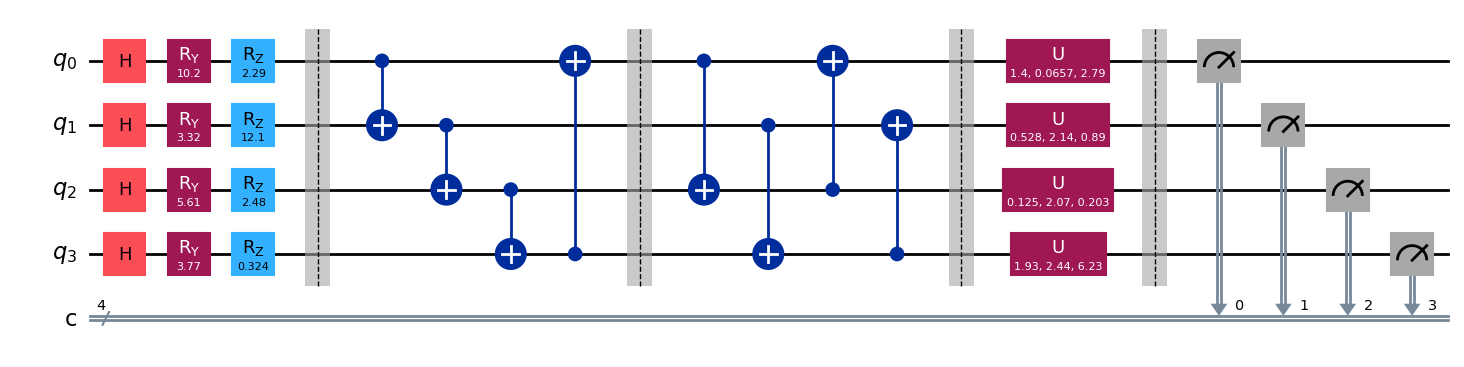

In [1]:
# 首先我们导入所有需要的包：
import deepquantum as dq
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# 我们设计的VQC线路如下 这里我们以4个bit作为例子
cir = dq.QubitCircuit(4)
cir.hlayer()
cir.rylayer(encode=True)
cir.rzlayer(encode=True)
cir.barrier()
cir.cnot_ring()
cir.barrier()
cir.cnot_ring(step=2)
cir.barrier()
cir.u3layer()
cir.barrier()
cir.measure()
cir.draw()  # 画出量子线路图

VQC 模块由三个主要部分构成：编码线路、变分线路以及量子测量。编码线路包含 H 门、Ry 门和 Rz 门，负责将信息编码至量子态。变分线路位于第1条和第4条虚线之间，其结构可以根据需要调整。量子比特的数量和量子测量的次数均可按实验需求进行灵活配置。此外，变分线路的层数和参数数量可以增加，以扩展模型规模，这主要取决于所使用的量子计算机或量子模拟软件的处理能力。在本节的示例中，所用的量子比特数量为4个。

### 量子RNN模型

在讲解量子 RNN 模型前，我们先简单回顾一下经典 RNN 模型的原理和结构（图2）。我们使用数学公式描述经典 RNN 模型的计算单元：

$$ h_t = \tanh(x_t W_{ih}^T + b_{ih} + h_{t-1}W_{hh}^T + b_{hh}) $$

其中 $ W_{ih} $ 是作用在 $ x_t $ 上的隐藏层权重参数， $ b_{ih} $ 是对应的隐藏层偏差参数， $ W_{hh} $ 是作用在 $ h_{t-1} $ 上的隐藏层权重参数， $ b_{hh} $ 是对应的隐藏层偏差参数，这里使用 tanh 函数作为激活函数。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_4_0002.png" width="50%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        图 2 </b>经典RNN模型示意图
    </p>
</div>

量子 RNN 模型是经典 RNN 模型的量子版本。主要区别在于经典神经网络被 VQC 取代，我们使用数学公式描述 QRNN 模型的计算单元 [1]：

$$
h_t = \tanh(VQC(v_t))
$$

$$
y_t = NN(h_t)
$$

其中输入 $ v_t $ 是前一个时间步长的隐藏状态 $ h_{t−1} $ 与当前输入向量 $ x_t $ 的级联， $ NN $ 是经典神经网络层。

首先我们先用DeepQuantum实现一个VQC模块：

In [2]:
## 定义VQC模块
class QuLinear(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        n_qubits = input_size  # 定义比特个数
        self.cir = dq.QubitCircuit(n_qubits, reupload=True)
        self.cir.hlayer()
        self.cir.rylayer(encode=True)
        self.cir.rzlayer(encode=True)
        self.cir.barrier()
        self.cir.cnot_ring()
        self.cir.barrier()
        self.cir.cnot_ring(step=2)
        self.cir.barrier()
        self.cir.u3layer()

        self.cir.barrier()  # 两层变分线路模块[1]
        self.cir.cnot_ring()
        self.cir.barrier()
        self.cir.cnot_ring(step=2)
        self.cir.barrier()
        self.cir.u3layer()

        for i in range(hidden_size):  # 以for循环
            self.cir.observable(wires=i, basis='z')

    def forward(self, x):
        ry_parameter = torch.arctan(x)  # 将经典数据转化为对应ry的角度
        rz_parameter = torch.arctan(x * x)  # 将经典数据转化为对应rz的角度
        r_parameter = torch.cat([ry_parameter, rz_parameter], dim=1)
        self.cir(r_parameter)
        return self.cir.expectation()

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/3_4_0003.png" width="50%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        图 3 </b> 量子RNN模型示意图
    </p>
</div>

图 3 展示了混合量子经典 RNN 的单元结构，结合前面章节的内容，不难发现，相比于经典结构，其中的线性全连接层被 VQC 线路替换，我们可以利用上面我们实现的 QuLinear，结合经典 RNN 的计算逻辑，实现量子混合经典循环神经网络。代码如下：

In [ ]:
class QRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.linear = QuLinear(input_size + hidden_size, hidden_size)
        self.tanh = nn.Tanh()

    def forward(self, x, h):
        v = torch.cat((x, h), dim=-1)
        h = self.tanh(self.linear(v))
        return h


class QrnnHybrid(nn.Module):
    def __init__(self, input_size, hidden_size, target_size, device):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.h0_linear = nn.Linear(hidden_size, hidden_size)
        self.gru = QRNNCell(input_size, hidden_size)
        self.tanh = nn.Tanh()
        self.device = device
        self.predictor = nn.Linear(hidden_size, target_size)

    def forward(self, x, hidden_state=None):
        # 初始化隐藏状态
        if hidden_state is None:
            batch_size, sequence_length, _ = x.size()
            h0 = self.tanh(self.h0_linear(torch.zeros(batch_size, self.hidden_size).to(self.device))).to(self.device)
            # 存储所有时间步的隐藏状态
            hidden_states = []
            # 遍历所有时间步
            for t in range(sequence_length):
                xt = x[:, t, :]
                ht = self.gru(xt, h0)
                hidden_states.append(ht.unsqueeze(1))
                h0 = ht
            output = self.predictor(torch.cat(hidden_states, dim=1))
            return output, hidden_states[-1]
        else:
            ht = self.gru(x[:, -1].unsqueeze(1), hidden_state)
            output = self.predictor(ht)
            return output, ht

In [ ]:
# 测试模型代码能否成功运行
# 定义输入、隐藏状态和输出的维度
input_size = 2  # 输入
hidden_size = 3
output_size = 1  # 输出一个数值
# 创建模型实例
device = torch.device('cpu')
model = QrnnHybrid(input_size, hidden_size, output_size, device)
# 随机生成输入数据
batch_size = 3
sequence_length = 4
input_data = torch.randn(batch_size, sequence_length, input_size)
# 前向传播
output, _ = model(input_data)
# 输出结果
print('输出的形状:', output.shape)

输出的形状: torch.Size([3, 4, 1])


## 量子RNN模型训练

本节将介绍量子 RNN 模型训练过程，包括训练的数据介绍，训练过程的代码实现。

### 数据任务

在这里，我们使用余弦函数作为模型训练的数据集，首先定义数据集构建函数，代码如下：

In [5]:
# 构建时间序列数据集
class TimeSeriesDataset(Dataset):
    def __init__(self, data, sequence_length):
        self.data = data
        self.sequence_length = sequence_length  # 定义数据长度
        self.xdata = []
        self.ydata = []
        for i in range(len(data)):
            if i + self.sequence_length + 1 > len(data):
                break
            self.xdata.append(self.data[i : i + self.sequence_length])  # xdata为输入数据
            self.ydata.append(self.data[i + 1 : i + self.sequence_length + 1])  # ydata为需要预测的后一位输出数据

    def __len__(self):
        return len(self.xdata)

    def __getitem__(self, index):
        x = self.xdata[index]
        y = self.ydata[index]  # 目标序列错开一位
        return x, y

我们给出范围在 $[0, 8\pi]$ 的余弦函数，振幅为0.5，将其分为200个数据点，取前100个数据点作为模型的训练数据，代码如下：

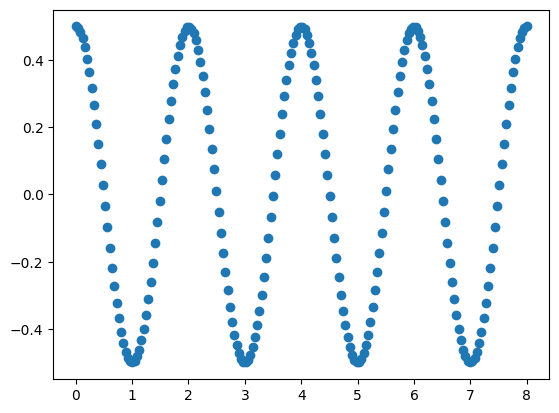

In [ ]:
start = 0
end = 8
data_points = 200
amplitude = 0.5
num_train_points = 100

time_steps = np.linspace(start, end, data_points)  # 在区间[0, 8*pi]之间线性均匀的选择200个数据点
data = np.cos(np.pi * time_steps) * amplitude  # 生成区间[0, 8*pi]上的余弦信号时间序列数据
train_data = data[:num_train_points]  # 选择前100个数据点作为训练集
test_data = data[num_train_points:]
# 创建数据集对象
# 由于第一个数据点不需要预测 而序列的最后一个数据点不能出现在训练的输入特征中 这里特征序列和标签序列的长度
# 都需要设为总长度-1
sequence_length = num_train_points - 1
dataset = TimeSeriesDataset(torch.tensor(train_data), sequence_length)
# 创建数据加载器
# 这里我们不做数据的窗口切分，因此每个batch中只有一条完整数据，并且只有一个batch
batch_size = 1
dataloader = DataLoader(dataset, batch_size=batch_size)

# 画出我们的数据集
plt.plot(time_steps, data, 'o')
plt.show()

### 全参数训练

在接下来的实验中，我们将利用上一小节中准备的数据集，以及基于上一节构建的 QRNN 模型来进行模型训练。实验中采用均方差损失函数（Mean Squared Error Loss，简称 MSELoss）作为训练过程中的损失函数。选用的优化器为 RMSprop[1]，这是一种基于梯度下降法的变体，它具备自适应学习率调整的特性。优化器的超参数配置如下：平滑常数alpha设为0.99，eps设为1e−8，动量（momentum）设为0.5。下面是定义模型训练函数的代码：

In [7]:
def trainer(model, epoch, learning_rate, device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.RMSprop(
        model.parameters(), learning_rate, alpha=0.99, eps=1e-08, weight_decay=0, momentum=0.5, centered=False
    )

    model = model.to(device)
    flag = False
    train_loss_list = []

    for e in range(epoch):
        if flag:
            break
        for x, y in dataloader:
            x = x.unsqueeze(-1).float()
            y = y.unsqueeze(-1).float()
            x = x.to(device)
            y = y.to(device)
            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss_list.append(loss.detach().numpy())
        print(f'Iteration: {e} loss {loss.item()}')

    metrics = {'epoch': list(range(1, len(train_loss_list) + 1)), 'train_loss': train_loss_list}
    return model, metrics

我们设置优化器的学习率 lr 为0.01，迭代次数为100次，模型中 VQC 的输入量子比特个数为1，隐藏层量子比特个数为3，输出量子比特个数为1。分别训练 QRNN，QLSTM 和 QGRU 模型，代码如下：

In [ ]:
# 训练混合量子经典RNN
lr = 0.01  # 定义学习率为0.01
epoch = 100  # 定义迭代次数为100次
device = torch.device('cpu')
model_qrnn = QrnnHybrid(1, 3, 1, device)

optim_model, metrics = trainer(model_qrnn, epoch, lr, device)

Iteration: 0 loss 0.11869426816701889
Iteration: 1 loss 0.10328350961208344
Iteration: 2 loss 0.06956392526626587
Iteration: 3 loss 0.04579199105501175
Iteration: 4 loss 0.023516254499554634
Iteration: 5 loss 0.010123389773070812
Iteration: 6 loss 0.004011716693639755
Iteration: 7 loss 0.0020131487399339676
Iteration: 8 loss 0.0019552072044461966
Iteration: 9 loss 0.001912047271616757
Iteration: 10 loss 0.001739197876304388
Iteration: 11 loss 0.001528664375655353
Iteration: 12 loss 0.001444532535970211
Iteration: 13 loss 0.0014012441970407963
Iteration: 14 loss 0.0013652406632900238
Iteration: 15 loss 0.0013189261080697179
Iteration: 16 loss 0.0012742872349917889
Iteration: 17 loss 0.0012345165014266968
Iteration: 18 loss 0.0011969645274803042
Iteration: 19 loss 0.0011605176841840148
Iteration: 20 loss 0.0011260064784437418
Iteration: 21 loss 0.0010937572224065661
Iteration: 22 loss 0.001063506817445159
Iteration: 23 loss 0.0010352241806685925
Iteration: 24 loss 0.0010089654242619872
I

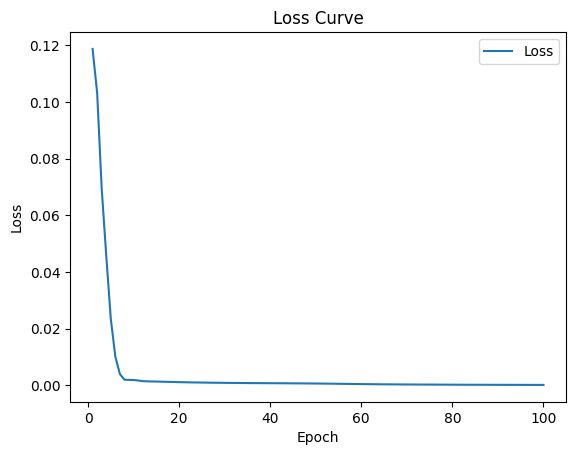

In [9]:
# 绘制QRNN模型的loss曲线
epoch = metrics['epoch']
loss = metrics['train_loss']

# 创建图和Axes对象
# 绘制训练损失曲线
plt.plot(epoch, loss, label='Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

## 参考文献
[1] Chen, S. Y. C., Fry, D., Deshmukh, A., Rastunkov, V., & Stefanski, C. (2022). Reservoir computing via quantum recurrent neural networks. arXiv preprint arXiv:2211.02612.

[2] Chen, S. Y. C., Yoo, S., & Fang, Y. L. L. (2022, May). Quantum long short-term memory. In ICASSP 2022-2022 IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP) (pp. 8622-8626). IEEE.